2026-04-14 15:12:42.402 | WARNING  | qpdk:<module>:30 - QPDK models could not be loaded (No module named 'jaxellip'). Ensure dependencies are installed with `pip install qpdk[models]`.


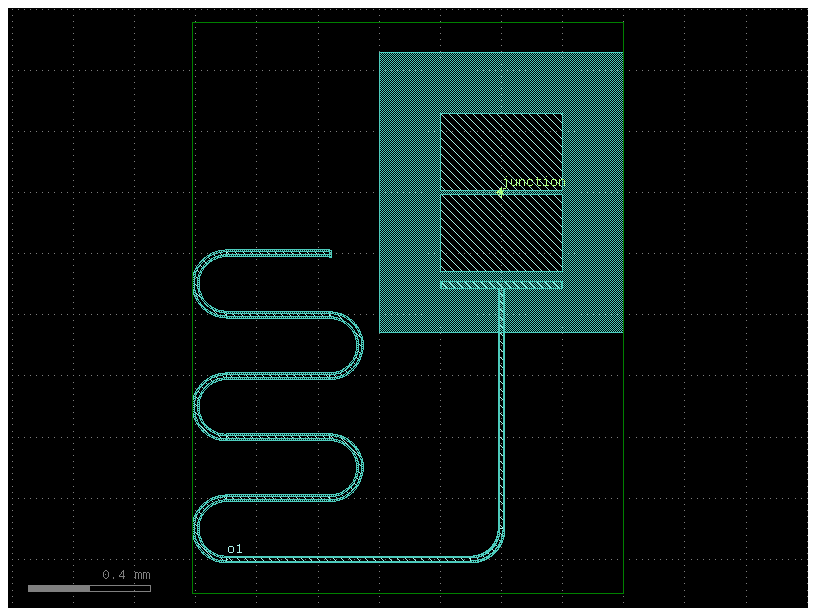

In [ ]:
import gdsfactory as gf
from qpdk import PDK, cells
from qpdk.cells.helpers import apply_additive_metals
from qpdk.tech import LAYER

PDK.activate()


@gf.cell
def transmon_component() -> gf.Component:
    """Create a qubit with resonator layout."""
    c = gf.Component()

    ref = c << cells.double_pad_transmon_with_resonator(
        qubit="double_pad_transmon_with_bbox",
        resonator_length=5000.0,
        resonator_meanders=5,
        qubit_rotation=90,
    )
    c.add_ports(ref.ports)

    # Match palace_qpdk_resonator pattern: keep CPW launch on x-boundary
    c.kdb_cell.shapes(LAYER.SIM_AREA).insert(c.bbox().enlarged(100, 100))

    return c


component = transmon_component()
_c = component.copy()
_c.draw_ports()
_c

### Inspect raw layers and apply additive metals

In [5]:
from gsim.common.polygon_utils import inspect_layers

inspect_layers(component, filename="transmon_raw_layers.png")

# Apply additive metals processing (QPDK-specific step)
processed = apply_additive_metals(component.copy())
inspect_layers(processed, filename="transmon_processed_layers.png")

### Convert QPDK etch layers to conductor geometry

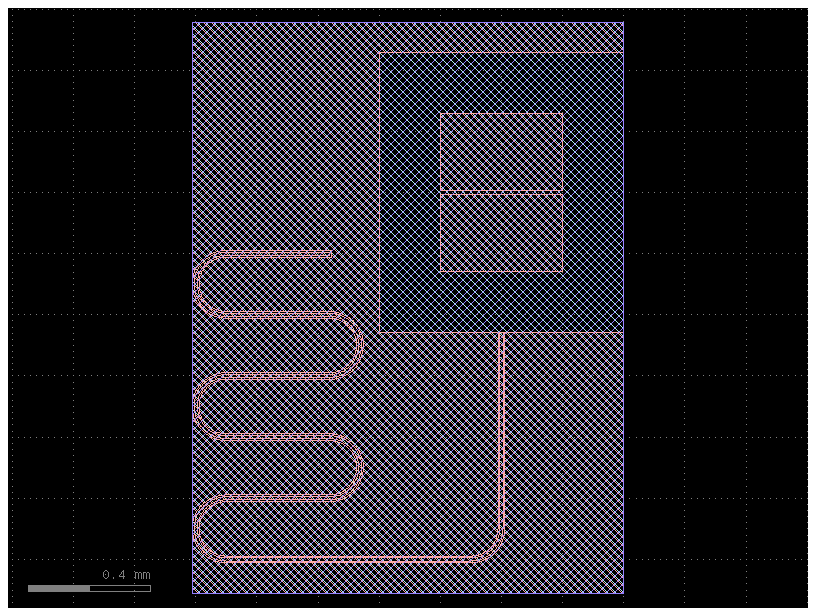

In [6]:
import warnings

import klayout.db as kdb
from qpdk.tech import LAYER as QPDK_LAYER

from gsim.common.polygon_utils import decimate

sim_area_layer = (QPDK_LAYER.SIM_AREA[0], QPDK_LAYER.SIM_AREA[1])
etch_layer = (QPDK_LAYER.M1_ETCH[0], QPDK_LAYER.M1_ETCH[1])

CPW_LAYERS = {"SUBSTRATE": (1, 0), "SUPERCONDUCTOR": (2, 0), "VACUUM": (3, 0)}

# Keep layer conversion aligned with palace_qpdk_resonator.ipynb
layout = component.kdb_cell.layout()
sim_region = kdb.Region(
    component.kdb_cell.begin_shapes_rec(layout.layer(*sim_area_layer))
)
etch_region = kdb.Region(component.kdb_cell.begin_shapes_rec(layout.layer(*etch_layer)))

etch_polys = decimate(list(etch_region.each()))
etch_region = kdb.Region()
for poly in etch_polys:
    etch_region.insert(poly)

if sim_region.is_empty():
    warnings.warn("No polygons found on SIM_AREA", stacklevel=2)
if etch_region.is_empty():
    warnings.warn("No polygons found on M1_ETCH", stacklevel=2)

conductor_region = sim_region - etch_region

# Unnamed component avoids KCell name collisions on repeated notebook runs
etched = gf.Component()
el = etched.kdb_cell.layout()
for name, region in [
    ("SUPERCONDUCTOR", conductor_region),
    ("SUBSTRATE", sim_region),
    ("VACUUM", sim_region),
]:
    idx = el.layer(*CPW_LAYERS[name])
    etched.kdb_cell.shapes(idx).insert(region)

for port in component.ports:
    etched.add_port(name=port.name, port=port)

inspect_layers(etched, filename="transmon_etched_layers.png")
etched

In [16]:
print("processed ports:", [p.name for p in processed.ports])
print("etched ports:", [p.name for p in etched.ports])
for p in etched.ports:
    print(
        p.name,
        "center=",
        p.center,
        "orientation=",
        p.orientation,
        "layer=",
        p.layer,
        "width=",
        p.width,
    )

processed ports: ['junction', 'o1']
etched ports: ['junction', 'o1']
junction center= (0.0, 0.0) orientation= 180.0 layer= JJ_AREA width= 33.446
o1 center= (-900.0, -1200.0) orientation= 0.0 layer= M1_DRAW width= 10.0


### Configure driven simulation

The junction is modeled as a reactive lumped element with a 10 nH inductance,
while the CPW port is used for excitation and S-parameter extraction.

In [7]:
from gsim.common.stack import Layer, LayerStack
from gsim.common.stack.materials import MATERIALS_DB
from gsim.palace import DrivenSim

# Build a CPW stack matching the etched component layers (avoid auto PDK resolution)
substrate_thickness = 500
vacuum_thickness = 500

stack = LayerStack(pdk_name="qpdk")
stack.layers["SUBSTRATE"] = Layer(
    name="SUBSTRATE",
    gds_layer=(1, 0),
    zmin=0.0,
    zmax=substrate_thickness,
    thickness=substrate_thickness,
    material="sapphire",
    layer_type="dielectric",
)
stack.layers["SUPERCONDUCTOR"] = Layer(
    name="SUPERCONDUCTOR",
    gds_layer=(2, 0),
    zmin=substrate_thickness,
    zmax=substrate_thickness,
    thickness=0,
    material="aluminum",
    layer_type="conductor",
)
stack.layers["VACUUM"] = Layer(
    name="VACUUM",
    gds_layer=(3, 0),
    zmin=substrate_thickness,
    zmax=substrate_thickness + vacuum_thickness,
    thickness=vacuum_thickness,
    material="vacuum",
    layer_type="dielectric",
)
stack.dielectrics = [
    {
        "name": "substrate",
        "zmin": 0.0,
        "zmax": substrate_thickness,
        "material": "sapphire",
    },
    {
        "name": "vacuum",
        "zmin": substrate_thickness,
        "zmax": substrate_thickness + vacuum_thickness,
        "material": "vacuum",
    },
]
stack.materials = {
    "sapphire": MATERIALS_DB["sapphire"].to_dict(),
    "aluminum": MATERIALS_DB["aluminum"].to_dict(),
    "vacuum": MATERIALS_DB["vacuum"].to_dict(),
}

sim = DrivenSim()
sim.set_geometry(etched)
sim.set_stack(stack)

# Junction element with 10 nH inductance (emitted as LumpedElement)
sim.add_port("junction", layer="SUPERCONDUCTOR", length=5.0, inductance=10e-9)

# CPW feed port for driven excitation (same pattern as working resonator notebook)
sim.add_cpw_port("o1", layer="SUPERCONDUCTOR", s_width=10.0, gap_width=6.0, offset=2.5)

sim.set_driven(fmin=4e9, fmax=8e9, num_points=41)

In [6]:
# Debug: verify configured Palace metadata on component ports
stack_dbg = sim._resolve_stack()
sim._configure_ports_on_component(stack_dbg)
for p in sim.geometry.component.ports:
    print(p.name, dict(p.info))

junction {'cross_section': '23bd1aae_33446', 'palace_type': 'lumped', 'layer': 'SUPERCONDUCTOR', 'length': 5.0, 'impedance': 50.0, 'excited': True, 'inductance': 1e-08}
o1 {'cross_section': '181c39e0_10000', 'palace_type': 'cpw', 'layer': 'SUPERCONDUCTOR', 'length': 0.1, 'impedance': 50.0, 'excited': True, 'cpw_upper_center': (-902.5, -1192.0), 'cpw_lower_center': (-902.5, -1208.0), 'cpw_gap_width': 6.0}


### Mesh and run

In [ ]:
sim.set_output_dir("./sim_qpdk_qubit_resonator_driven")
sim.mesh(preset="graded")
sim.plot_mesh(show_groups=["superconductor", "P", "sapphire", "vacuum"])

In [1]:
validation = sim.validate_mesh()
print(validation)
mesh_groups = sim._last_mesh_result.groups
print("port_surfaces:", mesh_groups.get("port_surfaces", {}))
print("port_info:", sim._last_mesh_result.port_info)

NameError: name 'sim' is not defined

In [9]:
from copy import deepcopy


def _try_cpw_params(orientation: float, offset: float):
    test_component = etched.copy()
    p0 = next(p for p in test_component.ports if p.name == "o1")
    test_component.add_port(
        name="o1",
        center=(float(p0.center[0]), float(p0.center[1])),
        width=float(p0.width),
        orientation=orientation,
        layer=p0.layer,
        port_type=getattr(p0, "port_type", "optical"),
    )

    test_sim = DrivenSim()
    test_sim.set_geometry(test_component)
    test_sim.set_stack(stack)
    test_sim.set_output_dir("./sim_qpdk_qubit_resonator_driven_probe")
    test_sim.add_port("junction", layer="SUPERCONDUCTOR", length=5.0, inductance=10e-9)
    test_sim.add_cpw_port(
        "o1",
        layer="SUPERCONDUCTOR",
        s_width=10.0,
        gap_width=6.0,
        length=5.0,
        offset=offset,
    )
    test_sim.set_driven(fmin=4e9, fmax=8e9, num_points=41)
    test_sim.mesh(preset="coarse")
    res = test_sim.validate_mesh()
    port_surfaces = test_sim._last_mesh_result.groups.get("port_surfaces", {})
    p2 = port_surfaces.get("P2", {})
    n_elem = len(p2.get("elements", [])) if p2.get("type") == "cpw" else -1
    return res.valid, n_elem, [str(e) for e in res.errors]


for ori in [0.0, 90.0, 180.0, 270.0]:
    for off in [0.0, 10.0, 20.0, 30.0, 50.0, 80.0]:
        ok, n_elem, errs = _try_cpw_params(ori, off)
        print(
            f"orientation={ori:>5.1f}, offset={off:>5.1f} -> cpw_elements={n_elem}, valid={ok}"
        )
        if n_elem >= 2:
            print("  candidate errors:", errs)

orientation=  0.0, offset=  0.0 -> cpw_elements=0, valid=False
orientation=  0.0, offset= 10.0 -> cpw_elements=0, valid=False
orientation=  0.0, offset= 20.0 -> cpw_elements=0, valid=False
orientation=  0.0, offset= 30.0 -> cpw_elements=0, valid=False
orientation=  0.0, offset= 50.0 -> cpw_elements=0, valid=False
orientation=  0.0, offset= 80.0 -> cpw_elements=0, valid=False
orientation= 90.0, offset=  0.0 -> cpw_elements=0, valid=False
orientation= 90.0, offset= 10.0 -> cpw_elements=0, valid=False
orientation= 90.0, offset= 20.0 -> cpw_elements=0, valid=False
orientation= 90.0, offset= 30.0 -> cpw_elements=0, valid=False
orientation= 90.0, offset= 50.0 -> cpw_elements=0, valid=False
orientation= 90.0, offset= 80.0 -> cpw_elements=0, valid=False
orientation=180.0, offset=  0.0 -> cpw_elements=0, valid=False
orientation=180.0, offset= 10.0 -> cpw_elements=0, valid=False
orientation=180.0, offset= 20.0 -> cpw_elements=0, valid=False
orientation=180.0, offset= 30.0 -> cpw_elements=0, vali

In [2]:
sim.write_config()
results = sim.run_local(num_processes=14)

if hasattr(results, "to_dataframe"):
    print("S-parameter summary")
    print("Ports:", results.port_names)
    results.plot(full=True)
    results.to_dataframe().head()
else:
    print("Simulation returned raw files:")
    print(results)

NameError: name 'sim' is not defined